# Machine Learning Engineer Nanodegree
## Reinforcement Learning
## Project: Train a Smartcab to Drive

Welcome to the fourth project of the Machine Learning Engineer Nanodegree! In this notebook, template code has already been provided for you to aid in your analysis of the *Smartcab* and your implemented learning algorithm. You will not need to modify the included code beyond what is requested. There will be questions that you must answer which relate to the project and the visualizations provided in the notebook. Each section where you will answer a question is preceded by a **'Question X'** header. Carefully read each question and provide thorough answers in the following text boxes that begin with **'Answer:'**. Your project submission will be evaluated based on your answers to each of the questions and the implementation you provide in `agent.py`.  

>**Note:** Code and Markdown cells can be executed using the **Shift + Enter** keyboard shortcut. In addition, Markdown cells can be edited by typically double-clicking the cell to enter edit mode.

-----

## Getting Started
In this project, you will work towards constructing an optimized Q-Learning driving agent that will navigate a *Smartcab* through its environment towards a goal. Since the *Smartcab* is expected to drive passengers from one location to another, the driving agent will be evaluated on two very important metrics: **Safety** and **Reliability**. A driving agent that gets the *Smartcab* to its destination while running red lights or narrowly avoiding accidents would be considered **unsafe**. Similarly, a driving agent that frequently fails to reach the destination in time would be considered **unreliable**. Maximizing the driving agent's **safety** and **reliability** would ensure that *Smartcabs* have a permanent place in the transportation industry.

**Safety** and **Reliability** are measured using a letter-grade system as follows:

| Grade 	| Safety 	| Reliability 	|
|:-----:	|:------:	|:-----------:	|
|   A+  	|  Agent commits no traffic violations,<br/>and always chooses the correct action. | Agent reaches the destination in time<br />for 100% of trips. |
|   A   	|  Agent commits few minor traffic violations,<br/>such as failing to move on a green light. | Agent reaches the destination on time<br />for at least 90% of trips. |
|   B   	| Agent commits frequent minor traffic violations,<br/>such as failing to move on a green light. | Agent reaches the destination on time<br />for at least 80% of trips. |
|   C   	|  Agent commits at least one major traffic violation,<br/> such as driving through a red light. | Agent reaches the destination on time<br />for at least 70% of trips. |
|   D   	| Agent causes at least one minor accident,<br/> such as turning left on green with oncoming traffic.       	| Agent reaches the destination on time<br />for at least 60% of trips. |
|   F   	|  Agent causes at least one major accident,<br />such as driving through a red light with cross-traffic.      	| Agent fails to reach the destination on time<br />for at least 60% of trips. |

To assist evaluating these important metrics, you will need to load visualization code that will be used later on in the project. Run the code cell below to import this code which is required for your analysis.

In [2]:
# Import the visualization code
import visuals as vs

# Pretty display for notebooks
%matplotlib inline

### Understand the World
Before starting to work on implementing your driving agent, it's necessary to first understand the world (environment) which the *Smartcab* and driving agent work in. One of the major components to building a self-learning agent is understanding the characteristics about the agent, which includes how the agent operates. To begin, simply run the `agent.py` agent code exactly how it is -- no need to make any additions whatsoever. Let the resulting simulation run for some time to see the various working components. Note that in the visual simulation (if enabled), the **white vehicle** is the *Smartcab*.

### Question 1
In a few sentences, describe what you observe during the simulation when running the default `agent.py` agent code. Some things you could consider:
- *Does the Smartcab move at all during the simulation?*
- *What kind of rewards is the driving agent receiving?*
- *How does the light changing color affect the rewards?*  

**Hint:** From the `/smartcab/` top-level directory (where this notebook is located), run the command 
```bash
'python smartcab/agent.py'
```

**Answer:**

1. The smartcab did not move at all during the simulation 

2. The driving agent is receiving mixed rewards: 

    Negative rewards While being idled at a green light with no incoming traffic. 

    And positive rewards while being idled at a green light with oncoming traffic or while being idled at a red light. This makes sense since the U.S. Right-of-Way rules apply to this environment. 

3. Answer above

### Understand the Code
In addition to understanding the world, it is also necessary to understand the code itself that governs how the world, simulation, and so on operate. Attempting to create a driving agent would be difficult without having at least explored the *"hidden"* devices that make everything work. In the `/smartcab/` top-level directory, there are two folders: `/logs/` (which will be used later) and `/smartcab/`. Open the `/smartcab/` folder and explore each Python file included, then answer the following question.

### Question 2
- *In the *`agent.py`* Python file, choose three flags that can be set and explain how they change the simulation.*
- *In the *`environment.py`* Python file, what Environment class function is called when an agent performs an action?*
- *In the *`simulator.py`* Python file, what is the difference between the *`'render_text()'`* function and the *`'render()'`* function?*
- *In the *`planner.py`* Python file, will the *`'next_waypoint()`* function consider the North-South or East-West direction first?*

**Answer:**

* agent.py: 
    * learning [boolean]: Whether the agent is expected to learn (if True then the agent is expected to learn).
        * default: False
    * epsilon: Random exploration factor (A factor of 0 will make the agent "myopic" (or short-sighted) by only considering current rewards, while a factor approaching 1 will make it strive for a long-term high reward). 
        * default: 1.0
    * alpha [0-1]: Learning factor (A factor of 0 will make the agent not learn anything, while a factor of 1 would make the agent consider only the most recent information).
        * default: 0.5

* environment.py: the act(self, agent, action) function is called when an agent performs an action (Consider an action and perform the action if it is legal. Receive a reward for the agent based on traffic laws).

* simulator.py: render_text(self, trial, testing=False) is the non-GUI render display of the simulation where the data is rendered in the terminal and render(self, trial, testing=False) on the other hand is the GUI render display of the simulation.

* planner.py: Yes. The 'next_waypoint() function will check first if the destination is at the current location,  then will check if destination is cardinally East or West of location and finally if destination is cardinally North or South of location.

-----
## Implement a Basic Driving Agent

The first step to creating an optimized Q-Learning driving agent is getting the agent to actually take valid actions. In this case, a valid action is one of `None`, (do nothing) `'Left'` (turn left), `'Right'` (turn right), or `'Forward'` (go forward). For your first implementation, navigate to the `'choose_action()'` agent function and make the driving agent randomly choose one of these actions. Note that you have access to several class variables that will help you write this functionality, such as `'self.learning'` and `'self.valid_actions'`. Once implemented, run the agent file and simulation briefly to confirm that your driving agent is taking a random action each time step.

### Basic Agent Simulation Results
To obtain results from the initial simulation, you will need to adjust following flags:
- `'enforce_deadline'` - Set this to `True` to force the driving agent to capture whether it reaches the destination in time.
- `'update_delay'` - Set this to a small value (such as `0.01`) to reduce the time between steps in each trial.
- `'log_metrics'` - Set this to `True` to log the simluation results as a `.csv` file in `/logs/`.
- `'n_test'` - Set this to `'10'` to perform 10 testing trials.

Optionally, you may disable to the visual simulation (which can make the trials go faster) by setting the `'display'` flag to `False`. Flags that have been set here should be returned to their default setting when debugging. It is important that you understand what each flag does and how it affects the simulation!

Once you have successfully completed the initial simulation (there should have been 20 training trials and 10 testing trials), run the code cell below to visualize the results. Note that log files are overwritten when identical simulations are run, so be careful with what log file is being loaded!
Run the agent.py file after setting the flags from projects/smartcab folder instead of projects/smartcab/smartcab.


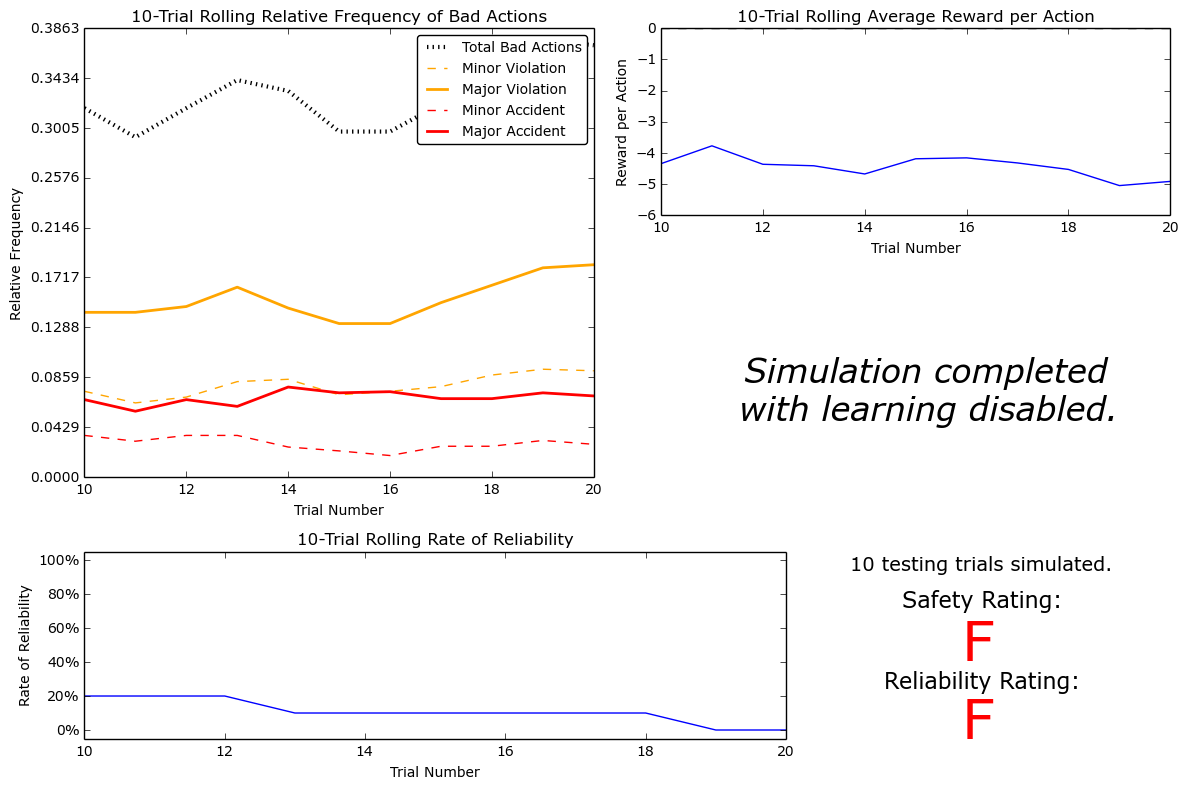

In [2]:
# Load the 'sim_no-learning' log file from the initial simulation results
vs.plot_trials('sim_no-learning.csv')

### Question 3
Using the visualization above that was produced from your initial simulation, provide an analysis and make several observations about the driving agent. Be sure that you are making at least one observation about each panel present in the visualization. Some things you could consider:
- *How frequently is the driving agent making bad decisions? How many of those bad decisions cause accidents?*
- *Given that the agent is driving randomly, does the rate of reliabilty make sense?*
- *What kind of rewards is the agent receiving for its actions? Do the rewards suggest it has been penalized heavily?*
- *As the number of trials increases, does the outcome of results change significantly?*
- *Would this Smartcab be considered safe and/or reliable for its passengers? Why or why not?*

**Answer:**

The driving agent is making bad decisions with a frequency between 32% and 34%. 4% caused minor accidents and 7% caused major accidents.

Yes, the rate of reliability given to the agent is F, meaning that the agent failed to reach the destination on time for at least 60% of trips, since the agent is making random decision this make sense.

The agent is receiving in average negative rewards for his actions, and since is frequently making bad decisions, this also make sense.

As the number of trials increases the results does not change significantly, except maybe the rate of reliability which decrease as the trails increases.

No, it would not be consider safe because the agent is taking random decision with a high frequency of accidents and a very low score on reliability.

-----
## Inform the Driving Agent
The second step to creating an optimized Q-learning driving agent is defining a set of states that the agent can occupy in the environment. Depending on the input, sensory data, and additional variables available to the driving agent, a set of states can be defined for the agent so that it can eventually *learn* what action it should take when occupying a state. The condition of `'if state then action'` for each state is called a **policy**, and is ultimately what the driving agent is expected to learn. Without defining states, the driving agent would never understand which action is most optimal -- or even what environmental variables and conditions it cares about!

### Identify States
Inspecting the `'build_state()'` agent function shows that the driving agent is given the following data from the environment:
- `'waypoint'`, which is the direction the *Smartcab* should drive leading to the destination, relative to the *Smartcab*'s heading.
- `'inputs'`, which is the sensor data from the *Smartcab*. It includes 
  - `'light'`, the color of the light.
  - `'left'`, the intended direction of travel for a vehicle to the *Smartcab*'s left. Returns `None` if no vehicle is present.
  - `'right'`, the intended direction of travel for a vehicle to the *Smartcab*'s right. Returns `None` if no vehicle is present.
  - `'oncoming'`, the intended direction of travel for a vehicle across the intersection from the *Smartcab*. Returns `None` if no vehicle is present.
- `'deadline'`, which is the number of actions remaining for the *Smartcab* to reach the destination before running out of time.

### Question 4
*Which features available to the agent are most relevant for learning both **safety** and **efficiency**? Why are these features appropriate for modeling the *Smartcab* in the environment? If you did not choose some features, why are those features* not *appropriate?*

**Answer:**

Since the rules the agent should follow in this example are quite simply the pseudo-code for the U.S. Right-of-Way can be writing as follows: 

* 'waypoint' = 'right' and 'light' = 'red' and  'left' = 'forward':
    * action = None
* 'waypoint' = 'left' and 'light' = 'green' and  ('oncoming' = 'forward' or 'oncoming' = 'right'):
    * action = None
* else:
    * action = follow waypoint according to light

'waypoint' is important for both safety and efficiency. The direction the agent should drive will influence both the steps it will take to reach the destination and the U.S. Right-of-Way rules applied to this environment.

'light' is the most important for safety.

'left' and 'oncoming' will also determine the actions the agent need to take to be in accordance with the U.S. Right-of-Way rules.

'deadline',is not important since the optimal direction the Smartcab should drive leading to the destination is provided in 'waypoint'. Also 'deadline' could influence the agent in making illegal moves when the deadline is near and if we were to include the deadline into our current state, our state space would blow up, we would suffer from the curse of dimensionality and it would take a long time for the q-matrix to converge.

'rigth' as stated in the pseudo code above this feature is not important according to the right of way rules.

### Define a State Space
When defining a set of states that the agent can occupy, it is necessary to consider the *size* of the state space. That is to say, if you expect the driving agent to learn a **policy** for each state, you would need to have an optimal action for *every* state the agent can occupy. If the number of all possible states is very large, it might be the case that the driving agent never learns what to do in some states, which can lead to uninformed decisions. For example, consider a case where the following features are used to define the state of the *Smartcab*:

`('is_raining', 'is_foggy', 'is_red_light', 'turn_left', 'no_traffic', 'previous_turn_left', 'time_of_day')`.

How frequently would the agent occupy a state like `(False, True, True, True, False, False, '3AM')`? Without a near-infinite amount of time for training, it's doubtful the agent would ever learn the proper action!

### Question 5
*If a state is defined using the features you've selected from **Question 4**, what would be the size of the state space? Given what you know about the evironment and how it is simulated, do you think the driving agent could learn a policy for each possible state within a reasonable number of training trials?*  
**Hint:** Consider the *combinations* of features to calculate the total number of states!

**Answer:**

The features and its possible values are:

* 'waypoint': ['forward', 'left', 'right']

* 'light': [True, False]  # True = NS open; False = EW open

* 'oncoming': [None, 'forward', 'left', 'right']

* 'left': [None, 'forward', 'left', 'right']

Space size = 3 ('waypoint') x 2 ('ligth') x 4 ('oncoming') x 4 ('left') = 96 states

Because there is 96 possible states and 4 actions that the agent could take in each one of them, the number of training trails should be at least 384. The number is somewhat high but for the agent to learn with a high degree of safety such number of trails will be necessary.

### Update the Driving Agent State
For your second implementation, navigate to the `'build_state()'` agent function. With the justification you've provided in **Question 4**, you will now set the `'state'` variable to a tuple of all the features necessary for Q-Learning. Confirm your driving agent is updating its state by running the agent file and simulation briefly and note whether the state is displaying. If the visual simulation is used, confirm that the updated state corresponds with what is seen in the simulation.

**Note:** Remember to reset simulation flags to their default setting when making this observation!

-----
## Implement a Q-Learning Driving Agent
The third step to creating an optimized Q-Learning agent is to begin implementing the functionality of Q-Learning itself. The concept of Q-Learning is fairly straightforward: For every state the agent visits, create an entry in the Q-table for all state-action pairs available. Then, when the agent encounters a state and performs an action, update the Q-value associated with that state-action pair based on the reward received and the interative update rule implemented. Of course, additional benefits come from Q-Learning, such that we can have the agent choose the *best* action for each state based on the Q-values of each state-action pair possible. For this project, you will be implementing a *decaying,* $\epsilon$*-greedy* Q-learning algorithm with *no* discount factor. Follow the implementation instructions under each **TODO** in the agent functions.

Note that the agent attribute `self.Q` is a dictionary: This is how the Q-table will be formed. Each state will be a key of the `self.Q` dictionary, and each value will then be another dictionary that holds the *action* and *Q-value*. Here is an example:

```
{ 'state-1': { 
    'action-1' : Qvalue-1,
    'action-2' : Qvalue-2,
     ...
   },
  'state-2': {
    'action-1' : Qvalue-1,
     ...
   },
   ...
}
```

Furthermore, note that you are expected to use a *decaying* $\epsilon$ *(exploration) factor*. Hence, as the number of trials increases, $\epsilon$ should decrease towards 0. This is because the agent is expected to learn from its behavior and begin acting on its learned behavior. Additionally, The agent will be tested on what it has learned after $\epsilon$ has passed a certain threshold (the default threshold is 0.01). For the initial Q-Learning implementation, you will be implementing a linear decaying function for $\epsilon$.

### Q-Learning Simulation Results
To obtain results from the initial Q-Learning implementation, you will need to adjust the following flags and setup:
- `'enforce_deadline'` - Set this to `True` to force the driving agent to capture whether it reaches the destination in time.
- `'update_delay'` - Set this to a small value (such as `0.01`) to reduce the time between steps in each trial.
- `'log_metrics'` - Set this to `True` to log the simluation results as a `.csv` file and the Q-table as a `.txt` file in `/logs/`.
- `'n_test'` - Set this to `'10'` to perform 10 testing trials.
- `'learning'` - Set this to `'True'` to tell the driving agent to use your Q-Learning implementation.

In addition, use the following decay function for $\epsilon$:

$$ \epsilon_{t+1} = \epsilon_{t} - 0.05, \hspace{10px}\textrm{for trial number } t$$

If you have difficulty getting your implementation to work, try setting the `'verbose'` flag to `True` to help debug. Flags that have been set here should be returned to their default setting when debugging. It is important that you understand what each flag does and how it affects the simulation! 

Once you have successfully completed the initial Q-Learning simulation, run the code cell below to visualize the results. Note that log files are overwritten when identical simulations are run, so be careful with what log file is being loaded!

### Also modify choose_action function

As stated above:
> "Of course, additional benefits come from Q-Learning, such that we can have the agent choose the best action for each state based on the Q-values of each state-action pair possible. "

Therefore:
> "As the best action would be to choose a random action from a choice of actions that have the highest Q-value. For example, since all actions are initialized with a reward of zero, it’s possible that all four actions are considered “optimal”. Not having the agent choose a random action from this would imply that it always chooses, perhaps, the first available option. This is incorrect behavior:"
```
STATE X:
-- ‘forward’ : 0.00
-- ‘left’    : 0.00
-- ‘right’   : -1.023
-- ‘None’    : 0.00
```
> "The agent should choose one of ‘forward’, ‘left’, or ‘None’ with equal probability, since they are all considered optimal with the current learned policy."

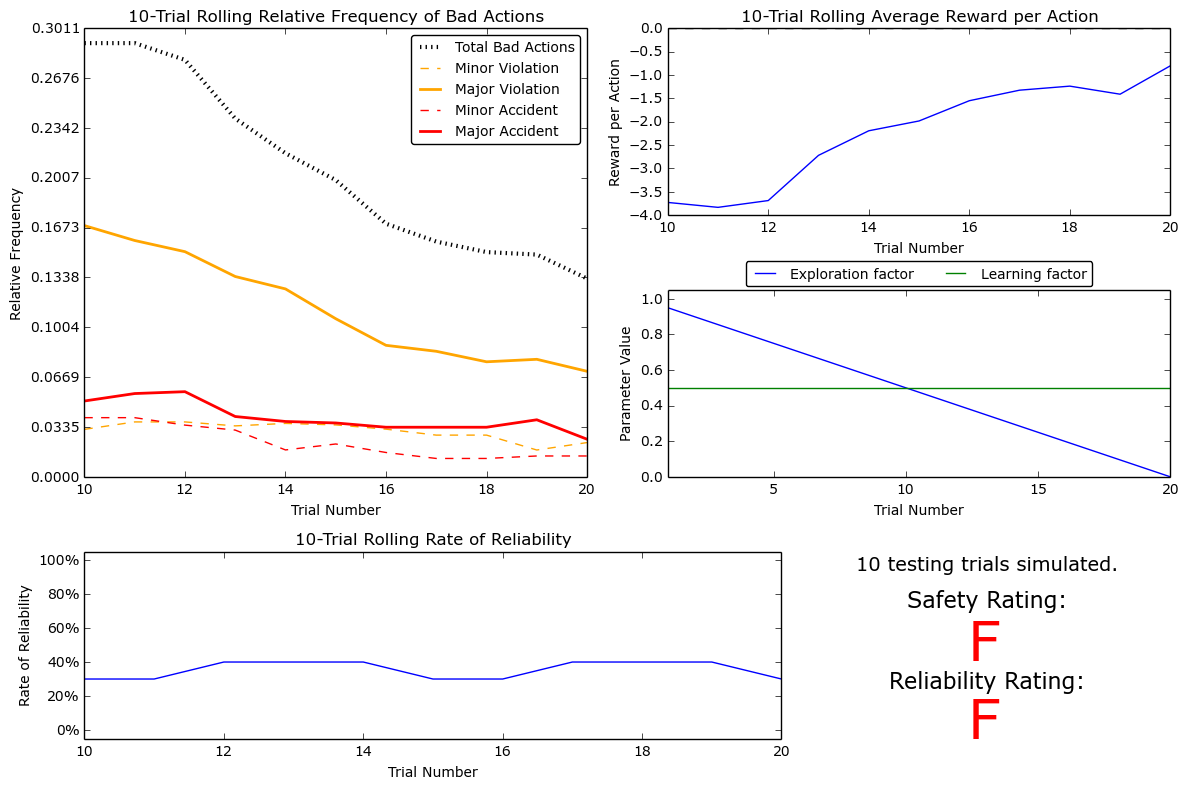

In [4]:
# Load the 'sim_default-learning' file from the default Q-Learning simulation
vs.plot_trials('sim_default-learning.csv')

### Question 6
Using the visualization above that was produced from your default Q-Learning simulation, provide an analysis and make observations about the driving agent like in **Question 3**. Note that the simulation should have also produced the Q-table in a text file which can help you make observations about the agent's learning. Some additional things you could consider:  
- *Are there any observations that are similar between the basic driving agent and the default Q-Learning agent?*
- *Approximately how many training trials did the driving agent require before testing? Does that number make sense given the epsilon-tolerance?*
- *Is the decaying function you implemented for $\epsilon$ (the exploration factor) accurately represented in the parameters panel?*
- *As the number of training trials increased, did the number of bad actions decrease? Did the average reward increase?*
- *How does the safety and reliability rating compare to the initial driving agent?*

**Answer:**

1. Yes, the Safety grade and the reliability grade are the same in both the basic driving agent and in the default Q-Learning agent. Although the Q-learning agent is making less bad decisions.

2. The agent required 20 training trails before the testing, it does makes sense: 

    $$ \epsilon_{t+1} = \epsilon_{t} - 0.05, \hspace{10px}\textrm{for trial number } t$$

    Therefore, 20 training trails should be done according to this function and the epsilon value.

3. Yes, the decaying function is decreasing 0.05 in each training trail, from the value 1 of until it reaches 0.

4. Yes, the total number of bad actions decreases. No, the average reward increased.

5. The safety and reliability grades are the same compare to the initial driving agent.

As state above, for the agent to learn with high degree of safety and reliability, at least 384 trails will be needed.

-----
## Improve the Q-Learning Driving Agent
The third step to creating an optimized Q-Learning agent is to perform the optimization! Now that the Q-Learning algorithm is implemented and the driving agent is successfully learning, it's necessary to tune settings and adjust learning paramaters so the driving agent learns both **safety** and **efficiency**. Typically this step will require a lot of trial and error, as some settings will invariably make the learning worse. One thing to keep in mind is the act of learning itself and the time that this takes: In theory, we could allow the agent to learn for an incredibly long amount of time; however, another goal of Q-Learning is to *transition from experimenting with unlearned behavior to acting on learned behavior*. For example, always allowing the agent to perform a random action during training (if $\epsilon = 1$ and never decays) will certainly make it *learn*, but never let it *act*. When improving on your Q-Learning implementation, consider the impliciations it creates and whether it is logistically sensible to make a particular adjustment.

### Improved Q-Learning Simulation Results
To obtain results from the initial Q-Learning implementation, you will need to adjust the following flags and setup:
- `'enforce_deadline'` - Set this to `True` to force the driving agent to capture whether it reaches the destination in time.
- `'update_delay'` - Set this to a small value (such as `0.01`) to reduce the time between steps in each trial.
- `'log_metrics'` - Set this to `True` to log the simluation results as a `.csv` file and the Q-table as a `.txt` file in `/logs/`.
- `'learning'` - Set this to `'True'` to tell the driving agent to use your Q-Learning implementation.
- `'optimized'` - Set this to `'True'` to tell the driving agent you are performing an optimized version of the Q-Learning implementation.

Additional flags that can be adjusted as part of optimizing the Q-Learning agent:
- `'n_test'` - Set this to some positive number (previously 10) to perform that many testing trials.
- `'alpha'` - Set this to a real number between 0 - 1 to adjust the learning rate of the Q-Learning algorithm.
- `'epsilon'` - Set this to a real number between 0 - 1 to adjust the starting exploration factor of the Q-Learning algorithm.
- `'tolerance'` - set this to some small value larger than 0 (default was 0.05) to set the epsilon threshold for testing.

Furthermore, use a decaying function of your choice for $\epsilon$ (the exploration factor). Note that whichever function you use, it **must decay to **`'tolerance'`** at a reasonable rate**. The Q-Learning agent will not begin testing until this occurs. Some example decaying functions (for $t$, the number of trials):

$$ \epsilon = a^t, \textrm{for } 0 < a < 1 \hspace{50px}\epsilon = \frac{1}{t^2}\hspace{50px}\epsilon = e^{-at}, \textrm{for } 0 < a < 1 \hspace{50px} \epsilon = \cos(at), \textrm{for } 0 < a < 1$$
You may also use a decaying function for $\alpha$ (the learning rate) if you so choose, however this is typically less common. If you do so, be sure that it adheres to the inequality $0 \leq \alpha \leq 1$.

If you have difficulty getting your implementation to work, try setting the `'verbose'` flag to `True` to help debug. Flags that have been set here should be returned to their default setting when debugging. It is important that you understand what each flag does and how it affects the simulation! 

Once you have successfully completed the improved Q-Learning simulation, run the code cell below to visualize the results. Note that log files are overwritten when identical simulations are run, so be careful with what log file is being loaded!

#### Exponential Decay

Exponential decay, tweaking variable $a$, $epsilon = 10 * e^{-at}, \textrm{for } 0 < a < 1$: 
![Exponential decay blog.nerdbucket.com](https://blog.nerdbucket.com/wp-content/uploads/2009/05/graph.jpg)

Red: a = 2

Green: a = 1

Blue: a = 0.5

Yellow: a = 0.25

Cyan: a = 0.125

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def exponential_decay(a):
    t = np.linspace(0, 384, 50)
    y = np.exp(-a * t)

    plt.figure()
    plt.plot(t, y)
    plt.xlabel('$t$')
    plt.ylabel('$exp(-a*t)$')
    plt.show()

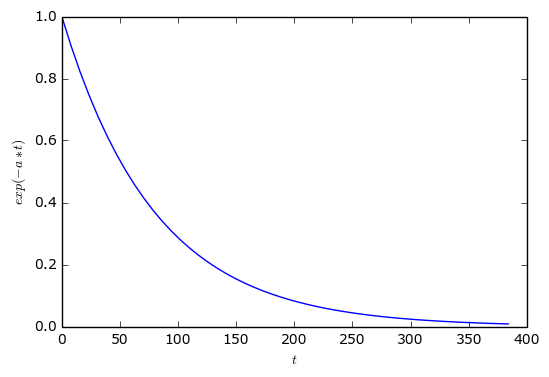

In [28]:
exponential_decay(0.0125)

In [6]:
# estimating the  minimum tolerance
import numpy as np
t = 384
a = - np.log(0.01) / t
print a

0.0119926306927


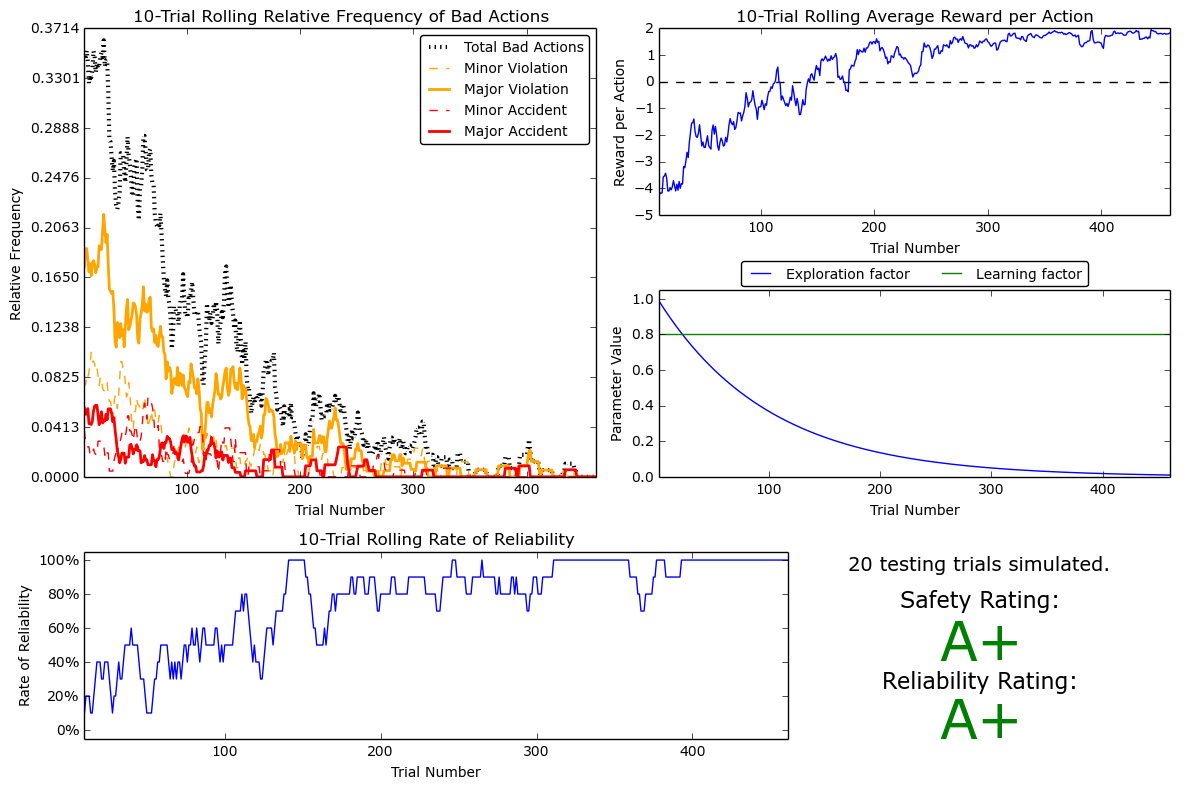

In [3]:
# Load the 'sim_improved-learning' file from the improved Q-Learning simulation
vs.plot_trials('sim_improved-learning.csv')

### Question 7
Using the visualization above that was produced from your improved Q-Learning simulation, provide a final analysis and make observations about the improved driving agent like in **Question 6**. Questions you should answer:  
- *What decaying function was used for epsilon (the exploration factor)?*
- *Approximately how many training trials were needed for your agent before begining testing?*
- *What epsilon-tolerance and alpha (learning rate) did you use? Why did you use them?*
- *How much improvement was made with this Q-Learner when compared to the default Q-Learner from the previous section?*
- *Would you say that the Q-Learner results show that your driving agent successfully learned an appropriate policy?*
- *Are you satisfied with the safety and reliability ratings of the *Smartcab*?*

**Answer:**

1. An exponential decay function was used for epsilon:
    $epsilon = e^{-at}, \textrm{for } 0 < a < 1$

2. The agent needed 461 training trails, this number differs from the objective of 384 training trails because variable $a$ was rounded to two decimals points (0.01).

3. I used the following values: 

    * tolerance = 0.01, as stated above I estimated the minimum number of training trials, considering the possible states and possible actions, for the agent to learn correctly both in safety and in reliability.
    
    * alpha = 0.8 so the new values for Q have more incidence, and the agent prioritize learning.

4. This Q-learner has made tremendous improvement from F and F ratings to A+ and A+ ratings in both Safety and Reliability.

5. Yes, the relative frequency of total bad actions made by this agent is near zero.  So the driver agent successfully learned the appropriate policy.

6. Yes, both the safety and reliability ratings are A+. Meaning the agent commits no traffic violations, and always chooses the correct action and the agent reaches the destination in time for 100% of trips.

### Improved Q-Learning Simulation Results 100 testing 

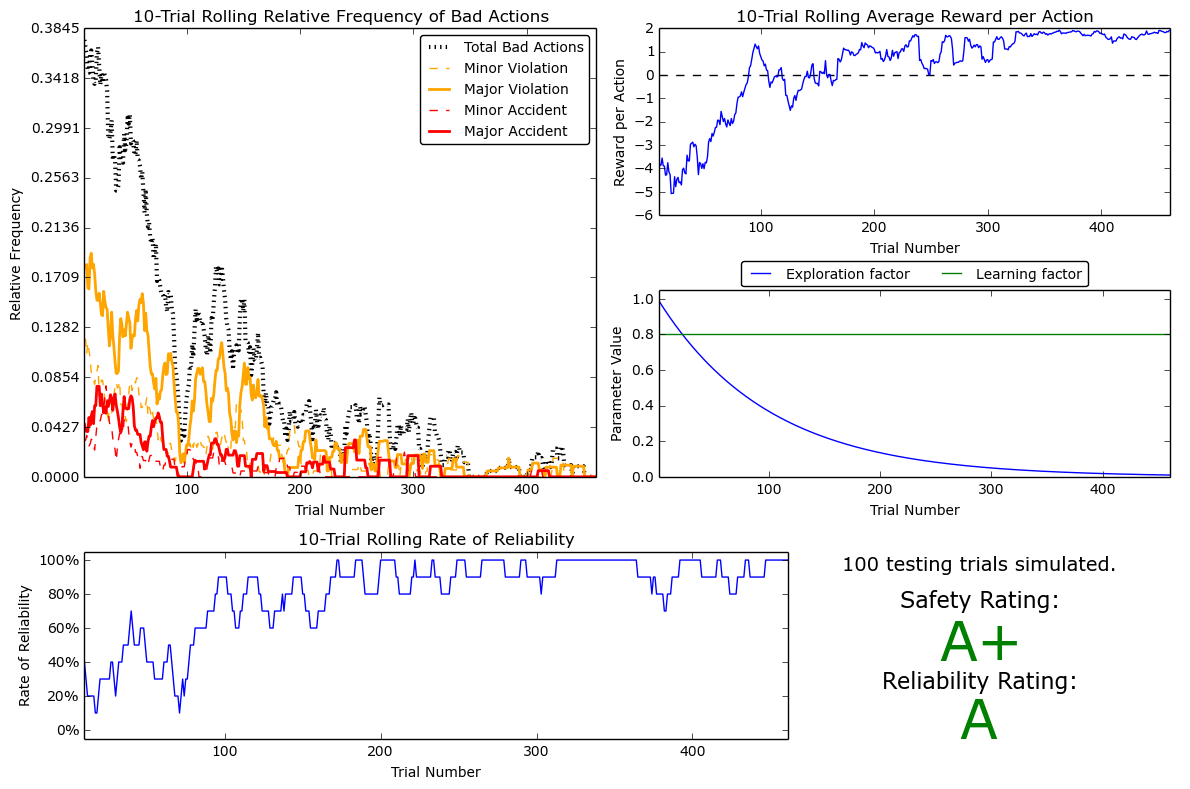

In [3]:
# Load the 'sim_improved-learning' file from the improved Q-Learning simulation
vs.plot_trials('sim_improved-learning.csv')

### Improved Q-Learning Simulation Results 100 testing with random maxQ

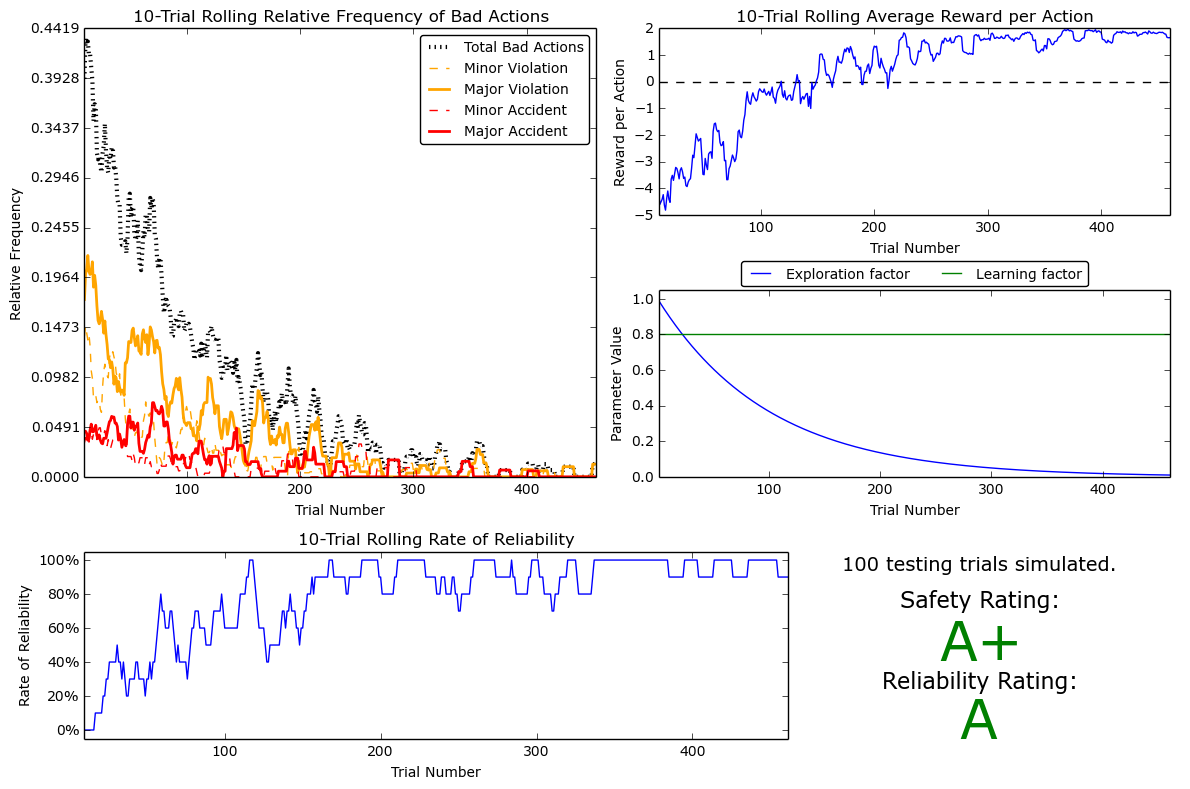

In [4]:
# Load the 'sim_improved-learning' file from the improved Q-Learning simulation
vs.plot_trials('sim_improved-learning.csv')

### Define an Optimal Policy

Sometimes, the answer to the important question *"what am I trying to get my agent to learn?"* only has a theoretical answer and cannot be concretely described. Here, however, you can concretely define what it is the agent is trying to learn, and that is the U.S. right-of-way traffic laws. Since these laws are known information, you can further define, for each state the *Smartcab* is occupying, the optimal action for the driving agent based on these laws. In that case, we call the set of optimal state-action pairs an **optimal policy**. Hence, unlike some theoretical answers, it is clear whether the agent is acting "incorrectly" not only by the reward (penalty) it receives, but also by pure observation. If the agent drives through a red light, we both see it receive a negative reward but also know that it is not the correct behavior. This can be used to your advantage for verifying whether the **policy** your driving agent has learned is the correct one, or if it is a **suboptimal policy**.

### Question 8
Provide a few examples (using the states you've defined) of what an optimal policy for this problem would look like. Afterwards, investigate the `'sim_improved-learning.txt'` text file to see the results of your improved Q-Learning algorithm. _For each state that has been recorded from the simulation, is the **policy** (the action with the highest value) correct for the given state? Are there any states where the policy is different than what would be expected from an optimal policy?_ Provide an example of a state and all state-action rewards recorded, and explain why it is the correct policy.

**Answer:** 


As stated above the pseudo-code for the U.S. Right-of-Way can be writing as follows: 

* 'waypoint' = 'right' and 'light' = 'red' and  'left' = 'forward':
    * action = None
* 'waypoint' = 'left' and 'light' = 'green' and  ('oncoming' = 'forward' or 'oncoming' = 'right'):
    * action = None
* else:
    * action = follow waypoint according to light

So the table with the optimal policy should be as follows (as stated above this is a simple example and the optimal policy can be concretely described):

|case| 'waypoint' | 'light' | 'left' | 'oncoming' | 'action' |
| :---------------:| :---------------: | :---------------------: | :--------------------: | :--------------: | :-------------: |
|1| right              |      red            |    forward    | any       |      None      |
|2| right              |      green            |    any    | any       |          right  |
|3| left               |        green          |         any    |            forward     |           None      |
|4| left               |        green          |         any    |            right     |           None      |
|5| left               |        green          |         any    |            any except right or forward     |           left      |
|6| left               |        red          |         any    |            any     |           None      |
|7| forward               |        red          |         any    |            any     |           None      |
|8| forward               |        green          |         any    |            any     |           forward      |

The policy is correct in most instances for the 8 cases:

1: 

```
('right', 'red', 'forward', None)
 -- forward : -38.95
 -- right : -19.08
 -- None : 2.11
 -- left : -40.61
```

2:
```
('right', 'green', 'forward', 'right')
 -- forward : 0.20
 -- right : 2.38
 -- None : -4.50
 -- left : -19.20
```

3:
```
('left', 'green', 'forward', None)
 -- forward : 0.77
 -- right : 0.26
 -- None : -5.55
 -- left : 2.27
```
4:
```
('left', 'green', 'right', None)
 -- forward : 0.38
 -- right : 0.94
 -- None : -5.46
 -- left : 2.12

```
5:
```
('left', 'green', 'left', 'left')
 -- forward : 0.84
 -- right : 0.05
 -- None : 0.13
 -- left : 2.76
```
6:
```
('left', 'red', 'right', None)
 -- forward : -9.56
 -- right : -0.22
 -- None : 2.54
 -- left : -8.99
```
7:
```
('forward', 'red', 'left', None)
 -- forward : -9.93
 -- right : 0.74
 -- None : 2.53
 -- left : -9.39
```
8:
```
('forward', 'green', 'right', 'forward')
 -- forward : 1.34
 -- right : 1.04
 -- None : 0.00
 -- left : -16.06
```

Yes, there some states where the policy is different from the optimal, for example:

```
('left', 'green', 'forward', 'right')
 -- forward : 0.00
 -- right : 0.81
 -- None : -4.23
 -- left : -16.22
```

```
('left', 'green', 'left', 'forward')
 -- forward : 1.45
 -- right : -0.01
 -- None : -4.68
 -- left : -15.61
```

This examples will be analyzed:

1. Optimal policy:

```
('right', 'red', 'forward', None)
 -- forward : -38.95
 -- right : -19.08
 -- None : 2.11
 -- left : -40.61
```
According to the  U.S. Right-of-Way rules on a red light, a right turn is permitted if no oncoming traffic is approaching from the left. This is consistent with the rewards since the action with the highest value (2.11) is None, meaning the agent should wait.

2. Sub-optimal policy:
```
('left', 'green', 'forward', 'right')
 -- forward : 0.00
 -- right : 0.81
 -- None : -4.23
 -- left : -16.22
```
On a green light, a left turn is permitted if there is no oncoming traffic making a right turn or coming forward. This case is consistent with the right of way rules, but optimal action the agent should have been choose 'left' instead of 'right'.

> "This state that we still see a 0.0 q-value. Thus probably more training trials would help the agent to encounter this state a bit more."

> "There are multiple dummy agents in this state. Therefore maybe look into increasing the number of dummy agents to learn more of the states in the beginning trials."


-----
### Optional: Future Rewards - Discount Factor, `'gamma'`
Curiously, as part of the Q-Learning algorithm, you were asked to **not** use the discount factor, `'gamma'` in the implementation. Including future rewards in the algorithm is used to aid in propogating positive rewards backwards from a future state to the current state. Essentially, if the driving agent is given the option to make several actions to arrive at different states, including future rewards will bias the agent towards states that could provide even more rewards. An example of this would be the driving agent moving towards a goal: With all actions and rewards equal, moving towards the goal would theoretically yield better rewards if there is an additional reward for reaching the goal. However, even though in this project, the driving agent is trying to reach a destination in the allotted time, including future rewards will not benefit the agent. In fact, if the agent were given many trials to learn, it could negatively affect Q-values!

### Optional Question 9
*There are two characteristics about the project that invalidate the use of future rewards in the Q-Learning algorithm. One characteristic has to do with the *Smartcab* itself, and the other has to do with the environment. Can you figure out what they are and why future rewards won't work for this project?*

**Answer:**

In the environment the rules of way applied, so even if the agent has more future reward, these laws must be respected to arrive at the destination safely.